### Check FEROS images and compare for several days

#### - import packages

In [1]:
%matplotlib inline
import os
import numpy as np
from astropy.io import fits
from astropy.wcs import WCS
import matplotlib
import matplotlib.pyplot as plt
import mpl_toolkits
from mpl_toolkits.axes_grid1 import make_axes_locatable
import math
from datetime import datetime
from astropy.io import ascii
from matplotlib import ticker, cm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from termcolor import colored
# define axis ranges
xl = 0
xu = 2148
yl = 0
yu = 4096


#### - define what images are selected
#### - write these images names to a new list

In [ ]:
from matplotlib import ticker, cm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

path      = '/home/angela/LaSilla/P117/FEROS/'
in_file   = path + 'list.lst'   # list all images

flat_img  = np.genfromtxt(in_file,dtype=np.str_)
num= 0
num_img = 0

keyw_obj  = "OBJECT"                       # object, e.g STD or target name
keyw_ext  = "EXPTIME"
keyw_lamp = "HIERARCH ESO INS CALMIRR2 ID "
select = input("Which object type to you want, eg BIAS, FLAT...:")
print("  ")
print("  ")

lamp  = "LAMP3"

#cal_lamp = "LAMP3"
if select == "FLAT":
    sel_expt_low = 10.00
if select ==  "WAVE":
    sel_expt_low = 40.0

#print("time selected:  ", sel_expt_low)

sel_expt_up  = sel_expt_low + 1.0

out_file = path +str(select)+"_select.lst"



# check if list of selected images exists, if yes delete it
if os.path.exists(out_file):
    os.remove(out_file)
else:
    print(colored('Sorry, I can not remove %s file!' % out_file,'red'))
    print("Create a new one")
    print("                ")
    print("                ")    


for item in flat_img:
    image_file=path+item
#   print(image_file)
    hdu_list = fits.open(image_file)
    header = fits.open(image_file)[0].header
    obj    = header[keyw_obj]
    exptime= header[keyw_ext]
    lam    = header[keyw_lamp]
#    print(image_file,obj)
    if obj == select and exptime >= sel_expt_low and exptime <=sel_expt_up:
#    if obj == select and exptime >= sel_expt_low and exptime <=sel_expt_up:        
        with open(out_file, "a") as text_file:
               print(item, file=text_file)
               num_img = num_img +1               # counts number of flat field image
               print(image_file, exptime)
    num=num+1
print("Number of images: ",num)    
print("Number of selected images: ", num_img)


### Define fuction plot_feros_data to create a figure with number of subplots

#### - total number of plots: 3 lines with 4 plots each

In [2]:
keyw_ext  = "EXPTIME"

def plot_feros_data(image,plt_num):
    image_file=image
    print(image_file)
    hdu_list = fits.open(image_file)
    header = fits.open(image_file)[0].header
    date_obs  = header[keyw_date] 
    exptime     = header[keyw_ext]
    img_data  = hdu_list[0].data
#    print(img_data.shape)
    line_data = hdu_list[0].data[2094:2095,0:2148]
#    hdu_list.info()
    axnum=plt.subplot(3,4,plt_num)
    img_stamp = axnum.imshow((img_data),cmap='hot_r',vmin=-0.01, vmax=600,origin='lower')  
    plt.xlim([1,2148])
    plt.ylim([1,4096])
    plt.text(x_min,4200,date_obs,fontdict=font)
    plt.text(100,3700,str(exptime)+"sec",color='white')
#    plt.xlim([0,500])
#    plt.ylim([0,500])    
    plt.xlabel("pixel", color="black")
    plt.ylabel("pixel",color="black")
    axnum.plot(cut_x,cut_y, color='blue')
    inset_axes_l = inset_axes(axnum,
                              width="30%", # width = 30% of parent_bbox
                              height="20%", # height : 20% of parrent_box
                              loc=1, borderpad=1.5,)
    inset_axes_l.plot(a, line_data[0],c='blue')
    inset_axes_l.tick_params(axis='x', colors='white')
    inset_axes_l.tick_params(axis='y', colors='white')

    plt.xlim([xstart,xstart+60])
    plt.ylim([0,25000])
#    plt.xticks([xstart,xstart+130])

plt.show()


### Creates the plots and the figure

flatfield_comp_2026-09-08.pdf
/home/angela/LaSilla/P115/FEROS/FEROS.2025-04-29T19:10:20.270.fits
/home/angela/LaSilla/P115/FEROS/FEROS.2025-08-14T16:06:49.510.fits
/home/angela/LaSilla/P116/FEROS/FEROS.2025-10-09T20:41:22.565.fits
/home/angela/LaSilla/P116/FEROS/FEROS.2026-02-14T17:39:21.423.fits
/home/angela/LaSilla/P116/FEROS/FEROS.2026-02-27T19:15:55.107.fits
/home/angela/LaSilla/P117/FEROS/FEROS.2026-07-02T15:50:40.944.fits
/home/angela/LaSilla/P117/FEROS/FEROS.2026-07-11T18:59:17.308.fits
/home/angela/LaSilla/P117/FEROS/FEROS.2026-07-13T16:46:22.602.fits
/home/angela/LaSilla/P117/FEROS/FEROS.2026-08-19T19:11:58.672.fits
/home/angela/LaSilla/P117/FEROS/FEROS.2026-08-25T15:37:22.495.fits
/home/angela/LaSilla/P117/FEROS/FEROS.2026-08-27T15:22:31.407.fits
/home/angela/LaSilla/P117/FEROS/FEROS.2026-09-08T16:21:54.737.fits


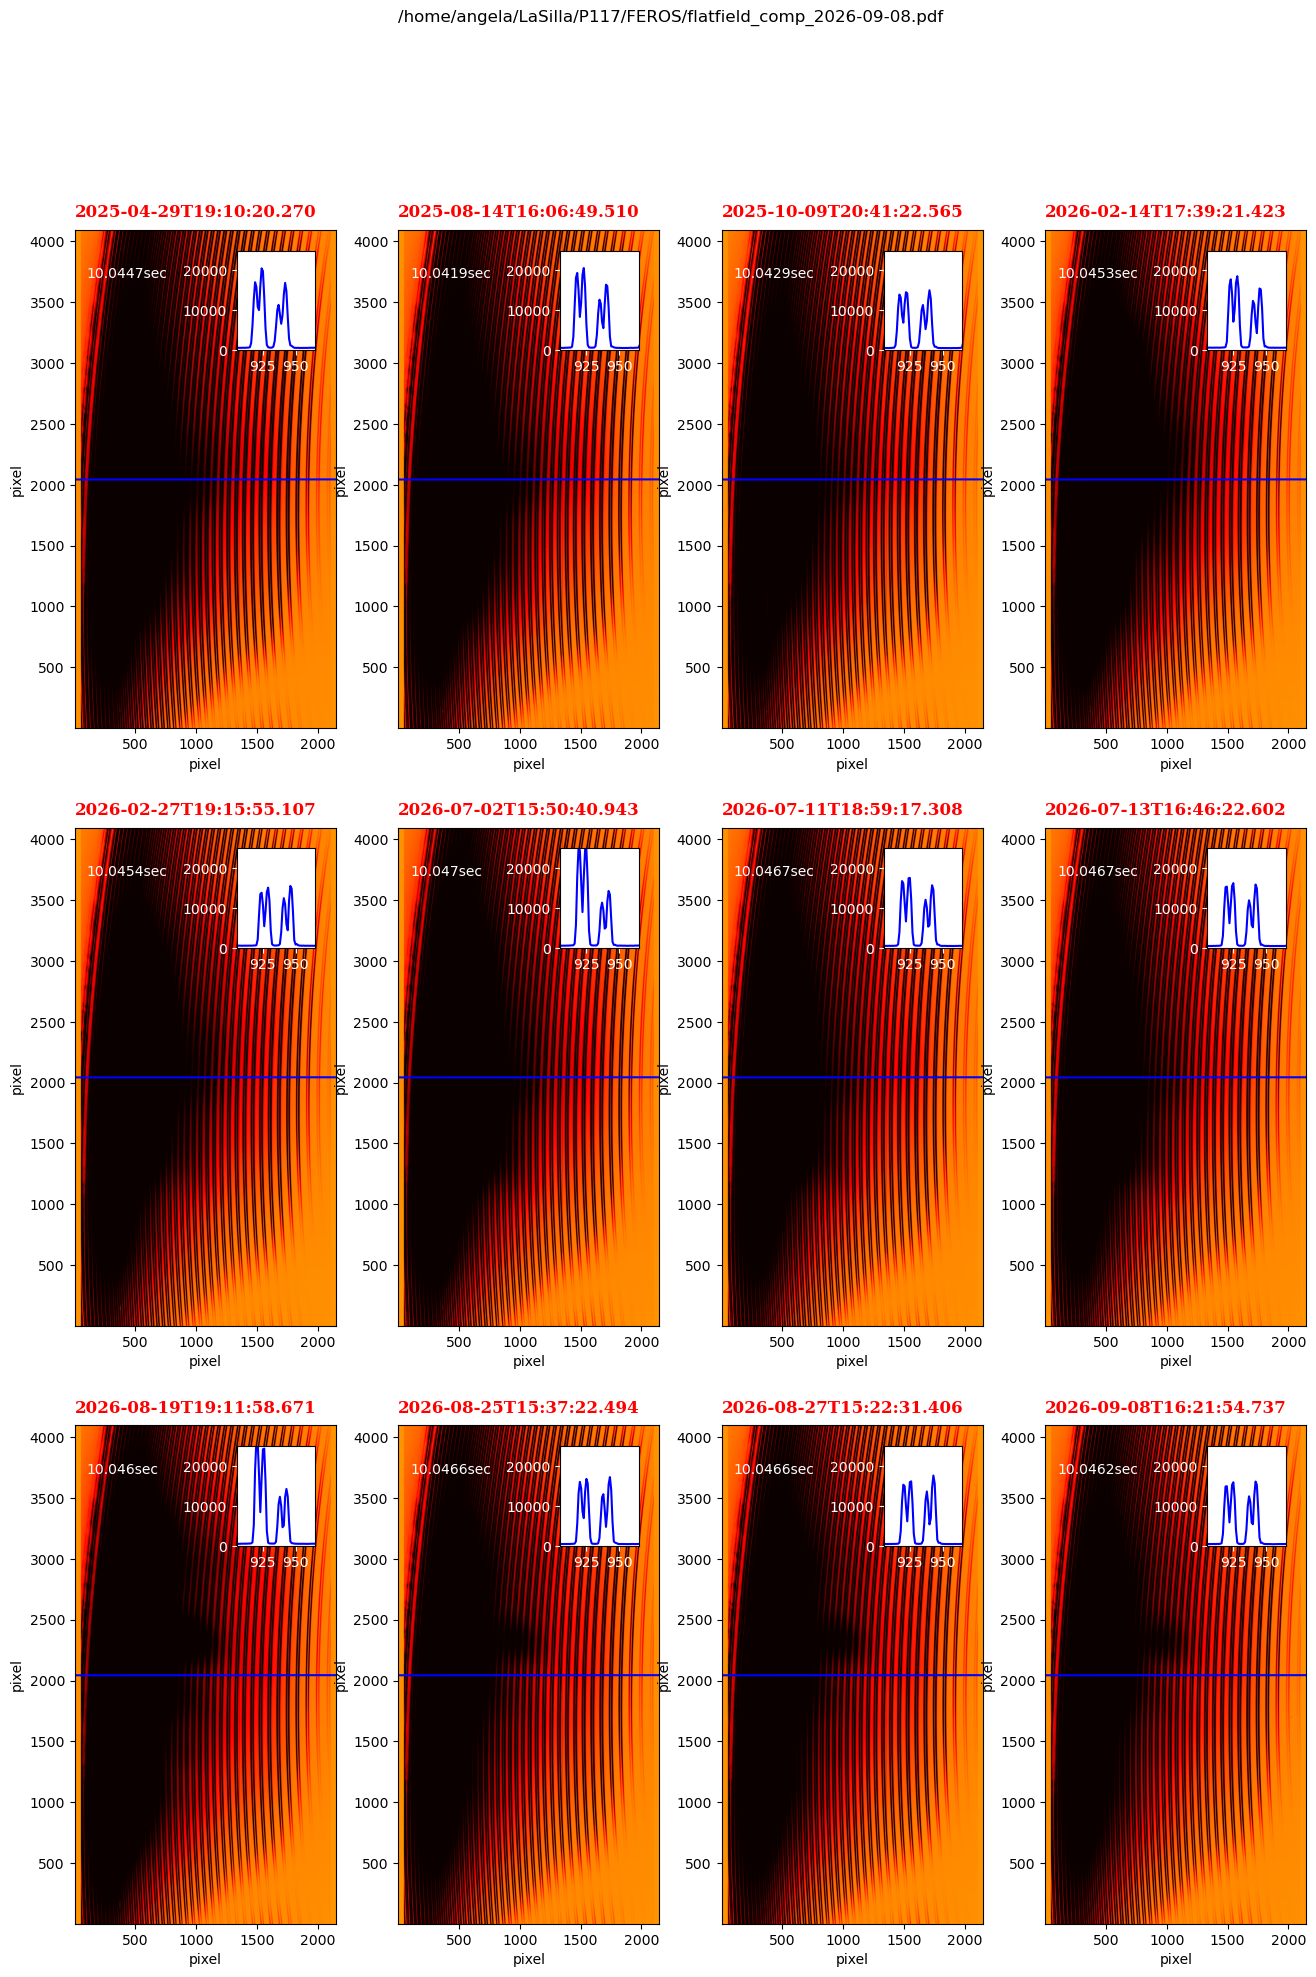

In [10]:
path      = '/home/angela/LaSilla/P117/FEROS/'
in_file   = path + 'FF-input.lst'   # list all bias frames

flat_img  = np.genfromtxt(in_file,dtype=np.str_)

date      = str(datetime.today().strftime('%Y-%m-%d'))

output='flatfield_comp_' +date +'.pdf'
print(output)

matplotlib.rcParams['figure.figsize'] = [16,22]
#plt.figure()
num=12
lines= math.ceil(num/4)
fig,axnum = plt.subplots(lines,4)
#fig, ax1 = plt.subplots(lines,4)

font = {'family': 'serif',
        'color':  'red',
        'weight': 'bold',
        'size': 12,
        }
    
#print(lines)
y_coo= 2043
xstart=905
plot_num = 1
x_min =  0
x_max =  2196
y_min =  y_coo-600
y_max =  y_coo+600
lines= math.ceil(num/4)
keyw_date  = "DATE-OBS"
cut_x= [x_min,x_max]
cut_y= [y_coo,y_coo+1]

a=np.arange(0,2148,1)
plot_num=1



for item in flat_img:
    header      = fits.open(item)[0].header
#    print(item)
    plot_feros_data(item,plot_num)
    plot_num=plot_num+1

    
fig.suptitle(path+output)    
    
plt.savefig(path+output)
plt.show()
plt.close()   


In [3]:
def calc_max(hdu_list,line,xstart):
    val= 2
    xstart_1  = xstart
    xend_1    = xstart_1+2*delta
    row_slice = hdu_list[0].data[line - 2 : line + 3, xstart_1:xend_1]

# 2. Get the maximum values and their relative row indexes (0 to 4)
    max_values = np.max(row_slice, axis=0)
    relative_row_indices = np.argmax(row_slice, axis=0)    
    sorted_rows = np.sort(row_slice, axis=0)
    column_top_val_sums = np.sum(sorted_rows[-val:, :], axis=0)

# 3. Create the X-axis coordinate array
    x_axis = np.arange(xstart_1, xend_1)
    flux_max = []
    line_res = []
    for i, x_coord in enumerate(range(xstart_1, xend_1)):
        true_line = (line - 2) + relative_row_indices[i]
        max_val   = max_values[i]

        line_res.append(true_line)         
        flux_max.append(max_values[i]) 
    return flux_max,line_res,x_axis

### Read 4 images to check line positions
#### * includes the whole path in case data from differen periods are used

In [4]:
date      = str(datetime.today().strftime('%Y-%m-%d'))
path_a      = '/home/angela/LaSilla/P117/FEROS/'
output=   path_a + "wave_comparison_"+ date+"_a.pdf"

in_file   = path_a + 'WAVE_select.lst'   # list all bias frames

wave_img  = np.genfromtxt(in_file,dtype=np.str_)

#print(wave_img)
img_a = wave_img[0]
img_b = wave_img[1]
img_c = wave_img[2]
img_d = wave_img[3]
print(img_a)
print(img_b)
print(img_c)
print(img_d)

/home/angela/LaSilla/P117/FEROS/FEROS.2026-07-02T16:55:39.387.fits
/home/angela/LaSilla/P117/FEROS/FEROS.2026-07-13T17:42:44.962.fits
/home/angela/LaSilla/P117/FEROS/FEROS.2026-09-08T17:23:13.780.fits
/home/angela/LaSilla/P117/FEROS/FEROS.2026-09-09T14:24:59.995.fits


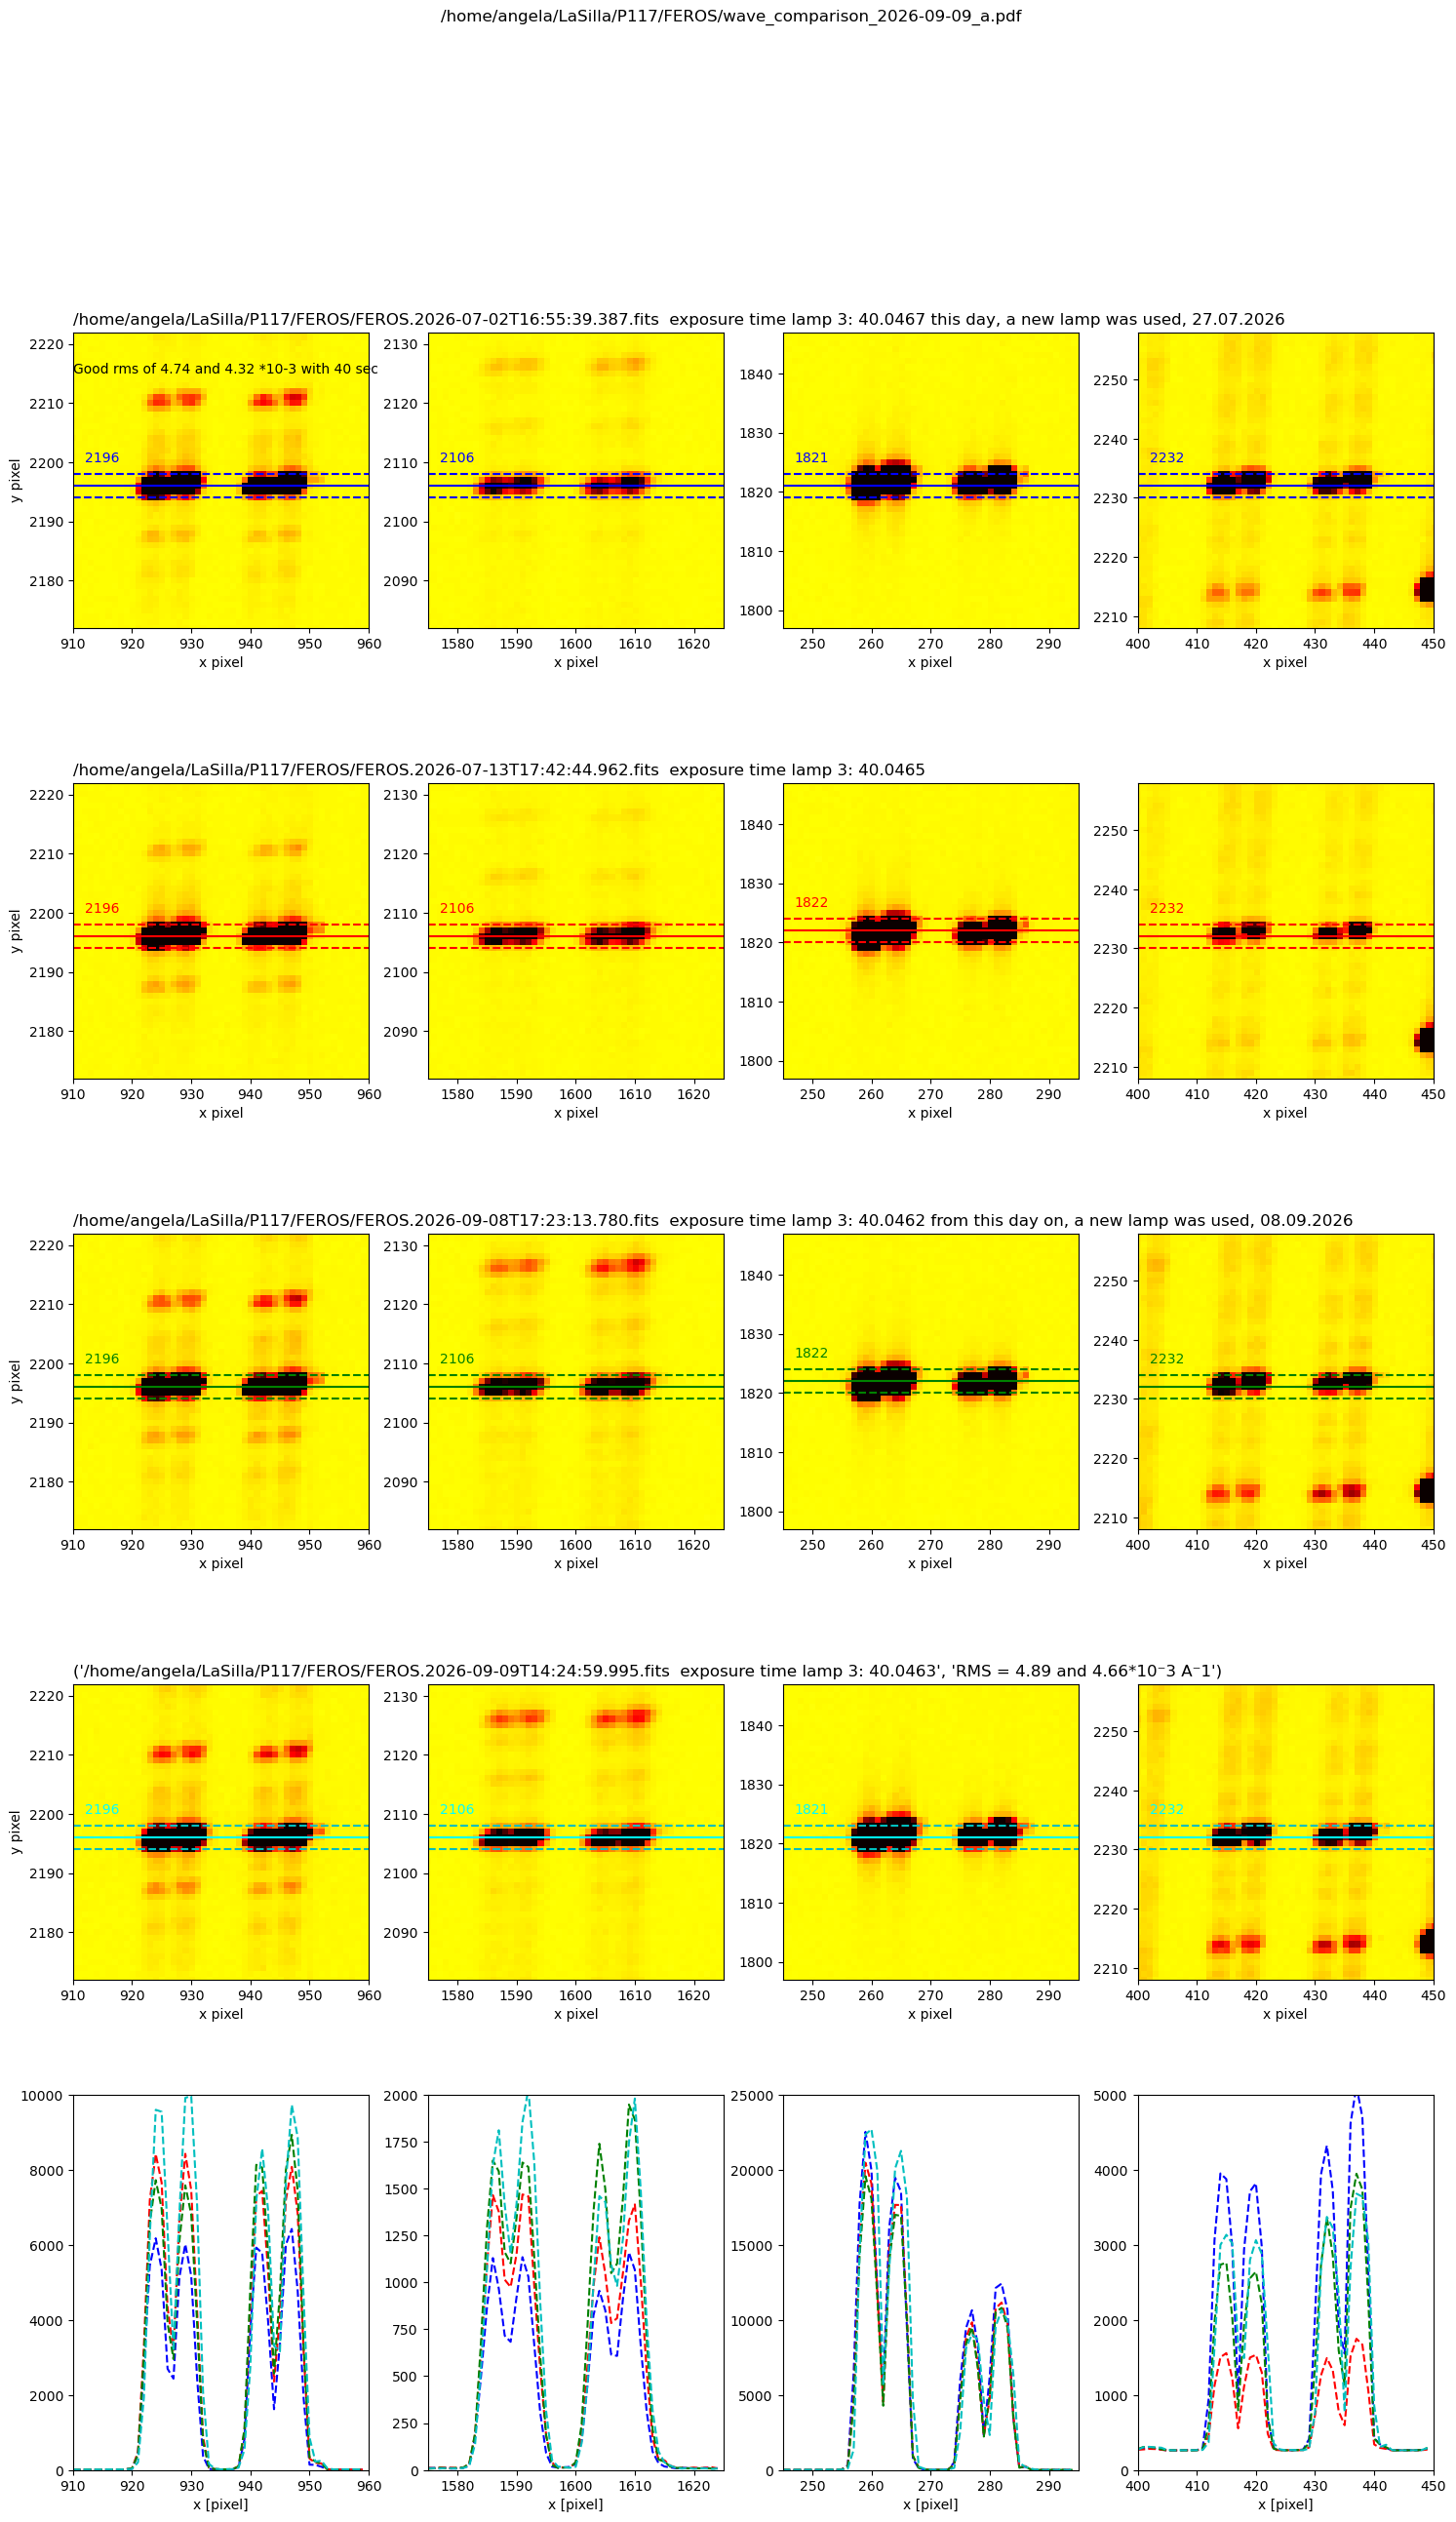

In [6]:
matplotlib.rcParams['figure.figsize'] = [19,27]
keyw_ext  = "EXPTIME"
delta  =  25
val    =    3
xstart_1  = 910 
xend_1    = xstart_1+2*delta
ystart_1  = 2197 - delta
yend_1    = ystart_1+2*delta


xstart_2  = 1575
xend_2    = xstart_2+2*delta
ystart_2  = 2107- delta
yend_2    = ystart_2 + 2*delta

xstart_3  = 245
xend_3    = xstart_3+2*delta
ystart_3  = 1822- delta
yend_3    = ystart_3 + 2*delta

xstart_4  =  400
xend_4    = xstart_4 + 2*delta
ystart_4  = 2233- delta
yend_4    = ystart_4 + 2*delta

b1 = np.arange(xstart_1,xend_1,1)
b2 = np.arange(xstart_2,xend_2,1)
b3 = np.arange(xstart_3,xend_3,1)
b4 = np.arange(xstart_4,xend_4,1)

fig,axnum = plt.subplots(5, 4, figsize=(18,29))

fig.suptitle(output) 
vmax=1000
vmin = -0.01

# Date 1

plt.subplot(5,4,1)
line = 2196
img         = img_a
hdu_list    = fits.open(img)
header      = fits.open(img)[0].header
exptime     = header[keyw_ext]
img_data    = hdu_list[0].data

line_data_1a = hdu_list[0].data[line:line+1,xstart_1:xend_1]

result        = calc_max(hdu_list,line,xstart_1)
flux_av_1     = np.array(result[0], dtype=np.uint16)
flux_line_1   = np.array(result[1], dtype=np.uint64)
xcoo_1        = np.array(result[2])

plt.imshow(img_data, cmap='hot_r',vmin=vmin, vmax=vmax,origin='lower')
plt.xlim([xstart_1,xend_1])
plt.ylim([ystart_1,yend_1])
plt.plot([xstart_1,xend_1],[line,line], color='blue')
plt.plot([xstart_1,xend_1],[line-2,line-2], 'b--')
plt.plot([xstart_1,xend_1],[line+2,line+2], 'b--')
plt.xlabel('x pixel')
plt.ylabel('y pixel')
plt.text(910,2215,"Good rms of 4.74 and 4.32 *10-3 with 40 sec")
#titel = img_a +"  exposure time lamp 3: " + str(exptime) + " this day, both fibers had a good rms from the pipeline"
titel = img_a +"  exposure time lamp 3: " + str(exptime)+ " this day, a new lamp was used, 27.07.2026"

plt.title(titel,loc='left')
plt.text(xstart_1+2,line+4,line,color='blue')


plt.subplot(5,4,2)
line= 2106
line_data_1b = hdu_list[0].data[line:line+1,xstart_2:xend_2]
plt.imshow(img_data, cmap='hot_r',vmin=vmin, vmax=vmax,origin='lower')
plt.xlim([xstart_2,xend_2])
plt.ylim([ystart_2,yend_2])
plt.plot([xstart_2,xend_2],[line,line], color='blue')
plt.plot([xstart_2,xend_2],[line-2,line-2], 'b--')
plt.plot([xstart_2,xend_2],[line+2,line+2], 'b--')
plt.xlabel('x pixel')
plt.text(xstart_2+2,line+4,line,color='blue')
result        = calc_max(hdu_list,line,xstart_2)
flux_av_2     = np.array(result[0], dtype=np.uint16)
flux_line_2   = np.array(result[1], dtype=np.uint64)
xcoo_2        = np.array(result[2])

plt.subplot(5,4,3)
line= 1821
line_data_1c = hdu_list[0].data[line:line+1,xstart_3:xend_3]
plt.imshow(img_data, cmap='hot_r',vmin=vmin, vmax=vmax,origin='lower')
plt.xlim([xstart_3,xend_3])
plt.ylim([ystart_3,yend_3])
plt.plot([xstart_3,xend_3],[line,line], color='blue')
plt.plot([xstart_3,xend_3],[line-2,line-2], 'b--')
plt.plot([xstart_3,xend_3],[line+2,line+2], 'b--')
plt.xlabel('x pixel')
plt.text(xstart_3+2,line+4,line,color='blue')
result      = calc_max(hdu_list,line,xstart_3)
flux_av_3     = np.array(result[0], dtype=np.uint16)
flux_line_3   = np.array(result[1], dtype=np.uint64)
xcoo_3        = np.array(result[2])

plt.subplot(5,4,4)
line= 2232
line_data_1d = hdu_list[0].data[line:line+1,xstart_4:xend_4]
plt.imshow(img_data, cmap='hot_r',vmin=vmin, vmax=vmax,origin='lower')
plt.xlim([xstart_4,xend_4])
plt.ylim([ystart_4,yend_4])
plt.plot([xstart_4,xend_4],[line,line], color='blue')
plt.plot([xstart_4,xend_4],[line-2,line-2], 'b--')
plt.plot([xstart_4,xend_4],[line+2,line+2], 'b--')
plt.xlabel('x pixel')
plt.text(xstart_4+2,line+4,line,color='blue')
result      = calc_max(hdu_list,line,xstart_4)
flux_av_4     = np.array(result[0], dtype=np.uint16)
flux_line_4   = np.array(result[1], dtype=np.uint64)
xcoo_4        = np.array(result[2])

# Date 2

plt.subplot(5,4,5)
line= 2196
img         = img_b
hdu_list    = fits.open(img)
header      = fits.open(img)[0].header
exptime     = header[keyw_ext]
img_data    = hdu_list[0].data
line_data_2a = hdu_list[0].data[line:line+1,xstart_1:xend_1]
plt.imshow(img_data, cmap='hot_r',vmin=vmin, vmax=vmax,origin='lower')
plt.xlim([xstart_1,xend_1])
plt.ylim([ystart_1,yend_1])
plt.plot([xstart_1,xend_1],[line,line], color='red')
plt.plot([xstart_1,xend_1],[line-2,line-2], 'r--')
plt.plot([xstart_1,xend_1],[line+2,line+2], 'r--')
plt.xlabel('x pixel')
plt.ylabel('y pixel')
#titel = img_b +"  exposure time lamp 3: " + str(exptime)
titel = img_b +"  exposure time lamp 3: " + str(exptime) 
plt.title(titel,loc='left')
plt.text(xstart_1+2,line+4,line,color='red')
result        = calc_max(hdu_list,line,xstart_1)
flux_av_5     = np.array(result[0], dtype=np.uint16)
flux_line_5   = np.array(result[1], dtype=np.uint64)
xcoo_5        = np.array(result[2])

plt.subplot(5,4,6)
line= 2106

line_data_2b = hdu_list[0].data[line:line+1,xstart_2:xend_2]
plt.imshow(img_data, cmap='hot_r',vmin=vmin, vmax=vmax,origin='lower')
plt.xlim([xstart_2,xend_2])
plt.ylim([ystart_2,yend_2])
plt.plot([xstart_2,xend_2],[line,line], color='red')
plt.plot([xstart_2,xend_2],[line-2,line-2], 'r--')
plt.plot([xstart_2,xend_2],[line+2,line+2], 'r--')
plt.xlabel('x pixel')
plt.text(xstart_2+2,line+4,line,color='red')
result        = calc_max(hdu_list,line,xstart_2)
flux_av_6     = np.array(result[0], dtype=np.uint16)
flux_line_6   = np.array(result[1], dtype=np.uint64)
xcoo_6        = np.array(result[2])

plt.subplot(5,4,7)
line= 1822
line_data_2c = hdu_list[0].data[line:line+1,xstart_3:xend_3]
plt.imshow(img_data, cmap='hot_r',vmin=vmin, vmax=vmax,origin='lower')
plt.xlim([xstart_3,xend_3])
plt.ylim([ystart_3,yend_3])
plt.plot([xstart_3,xend_3],[line,line], color='red')
plt.plot([xstart_3,xend_3],[line-2,line-2], 'r--')
plt.plot([xstart_3,xend_3],[line+2,line+2], 'r--')
plt.xlabel('x pixel')
plt.text(xstart_3+2,line+4,line,color='red')
result        = calc_max(hdu_list,line,xstart_3)
flux_av_7     = np.array(result[0], dtype=np.uint16)
flux_line_7   = np.array(result[1], dtype=np.uint64)
xcoo_7        = np.array(result[2])

plt.subplot(5,4,8)
line= 2232
line_data_2d = hdu_list[0].data[line:line+1,xstart_4:xend_4]
plt.imshow(img_data, cmap='hot_r',vmin=vmin, vmax=vmax,origin='lower')
plt.xlim([xstart_4,xend_4])
plt.ylim([ystart_4,yend_4])
plt.plot([xstart_4,xend_4],[line,line], color='red')
plt.plot([xstart_4,xend_4],[line-2,line-2], 'r--')
plt.plot([xstart_4,xend_4],[line+2,line+2], 'r--')
plt.xlabel('x pixel')
plt.text(xstart_4+2,line+4,line,color='red')
result        = calc_max(hdu_list,line,xstart_4)
flux_av_8     = np.array(result[0], dtype=np.uint16)
flux_line_8   = np.array(result[1], dtype=np.uint64)
xcoo_8        = np.array(result[2])



# Date 3

plt.subplot(5,4,9)
line= 2196
img         = img_c
hdu_list    = fits.open(img)
header      = fits.open(img)[0].header
exptime     = header[keyw_ext]
img_data    = hdu_list[0].data
#line_data_a = hdu_list[0].data[line-1:line,xstart:xend]
line_data_3a = hdu_list[0].data[line:line+1,xstart_1:xend_1]
plt.imshow(img_data, cmap='hot_r',vmin=vmin, vmax=vmax,origin='lower')
plt.xlim([xstart_1,xend_1])
plt.ylim([ystart_1,yend_1])
plt.plot([xstart_1,xend_1],[line,line], color='green')
plt.plot([xstart_1,xend_1],[line-2,line-2], 'g--')
plt.plot([xstart_1,xend_1],[line+2,line+2], 'g--')
plt.xlabel('x pixel')
plt.ylabel('y pixel')
#plt.text(920,2215,"Good rms of 4.49*10-3 with 30 sec")
titel = img_c +"  exposure time lamp 3: " + str(exptime) + " from this day on, a new lamp was used, 08.09.2026"
plt.title(titel,loc='left')
plt.text(xstart_1+2,line+4,line,color='green')
result        = calc_max(hdu_list,line,xstart_1)
flux_av_9     = np.array(result[0], dtype=np.uint16)
flux_line_9   = np.array(result[1], dtype=np.uint64)
xcoo_9        = np.array(result[2])

plt.subplot(5,4,10)
line= 2106
line_data_3b = hdu_list[0].data[line:line+1,xstart_2:xend_2]
plt.imshow(img_data, cmap='hot_r',vmin=vmin, vmax=vmax,origin='lower')
plt.xlim([xstart_2,xend_2])
plt.ylim([ystart_2,yend_2])
plt.plot([xstart_2,xend_2],[line,line], color='green')
plt.plot([xstart_2,xend_2],[line-2,line-2], 'g--')
plt.plot([xstart_2,xend_2],[line+2,line+2], 'g--')
plt.xlabel('x pixel')
plt.text(xstart_2+2,line+4,line,color='green')
result        = calc_max(hdu_list,line,xstart_2)
flux_av_10    = np.array(result[0], dtype=np.uint16)
flux_line_10  = np.array(result[1], dtype=np.uint64)
xcoo_10        = np.array(result[2])

plt.subplot(5,4,11)
line= 1822
line_data_3c = hdu_list[0].data[line:line+1,xstart_3:xend_3]
plt.imshow(img_data, cmap='hot_r',vmin=vmin, vmax=vmax,origin='lower')
plt.xlim([xstart_3,xend_3])
plt.ylim([ystart_3,yend_3])
plt.plot([xstart_3,xend_3],[line,line], color='green')
plt.plot([xstart_3,xend_3],[line-2,line-2], 'g--')
plt.plot([xstart_3,xend_3],[line+2,line+2], 'g--')
plt.xlabel('x pixel')
plt.text(xstart_3+2,line+4,line,color='green')
result        = calc_max(hdu_list,line,xstart_3)
flux_av_11    = np.array(result[0], dtype=np.uint16)
flux_line_11  = np.array(result[1], dtype=np.uint64)
xcoo_11       = np.array(result[2])

plt.subplot(5,4,12)
line= 2232
line_data_3d = hdu_list[0].data[line:line+1,xstart_4:xend_4]
plt.imshow(img_data, cmap='hot_r',vmin=vmin, vmax=vmax,origin='lower')
plt.xlim([xstart_4,xend_4])
plt.ylim([ystart_4,yend_4])
plt.plot([xstart_4,xend_4],[line,line], color='green')
plt.plot([xstart_4,xend_4],[line-2,line-2], 'g--')
plt.plot([xstart_4,xend_4],[line+2,line+2], 'g--')
plt.xlabel('x pixel')
plt.text(xstart_4+2,line+4,line,color='green')
result        = calc_max(hdu_list,line,xstart_4)
flux_av_12    = np.array(result[0], dtype=np.uint16)
flux_line_12  = np.array(result[1], dtype=np.uint64)
xcoo_12       = np.array(result[2])

# Date 4

plt.subplot(5,4,13)
line= 2196
img         = img_d
hdu_list    = fits.open(img)
header      = fits.open(img)[0].header
exptime     = header[keyw_ext]
img_data    = hdu_list[0].data
#line_data_a = hdu_list[0].data[line-1:line,xstart:xend]
line_data_4a = hdu_list[0].data[line:line+1,xstart_1:xend_1]
plt.imshow(img_data, cmap='hot_r',vmin=vmin, vmax=vmax,origin='lower')
plt.xlim([xstart_1,xend_1])
plt.ylim([ystart_1,yend_1])
plt.plot([xstart_1,xend_1],[line,line], color='cyan')
plt.plot([xstart_1,xend_1],[line-2,line-2], 'c--')
plt.plot([xstart_1,xend_1],[line+2,line+2], 'c--')
plt.xlabel('x pixel')
plt.ylabel('y pixel')
titel = img_d + "  exposure time lamp 3: "+str(exptime) , "RMS = 4.89 and 4.66*10⁻3 A⁻1"
plt.title(titel,loc='left')
plt.text(xstart_1+2,line+4,line,color='cyan')
#plt.text(920,2215,"Good rms of 4.5*10-3, 4.25*10-3")
result        = calc_max(hdu_list,line,xstart_1)
flux_av_13    = np.array(result[0], dtype=np.uint16)
flux_line_13  = np.array(result[1], dtype=np.uint64)
xcoo_13       = np.array(result[2])

plt.subplot(5,4,14)
line= 2106
line_data_4b = hdu_list[0].data[line:line+1,xstart_2:xend_2]
plt.imshow(img_data, cmap='hot_r',vmin=vmin, vmax=vmax,origin='lower')
plt.xlim([xstart_2,xend_2])
plt.ylim([ystart_2,yend_2])
plt.plot([xstart_2,xend_2],[line,line], color='cyan')
plt.plot([xstart_2,xend_2],[line-2,line-2], 'c--')
plt.plot([xstart_2,xend_2],[line+2,line+2], 'c--')
plt.xlabel('x pixel')
plt.text(xstart_2+2,line+4,line,color='cyan')
result        = calc_max(hdu_list,line,xstart_2)
flux_av_14    = np.array(result[0], dtype=np.uint16)
flux_line_14  = np.array(result[1], dtype=np.uint64)
xcoo_14        = np.array(result[2])

plt.subplot(5,4,15)
line= 1821
line_data_4c = hdu_list[0].data[line:line+1,xstart_3:xend_3]
plt.imshow(img_data, cmap='hot_r',vmin=vmin, vmax=vmax,origin='lower')
plt.xlim([xstart_3,xend_3])
plt.ylim([ystart_3,yend_3])
plt.plot([xstart_3,xend_3],[line,line], color='cyan')
plt.plot([xstart_3,xend_3],[line-2,line-2], 'c--')
plt.plot([xstart_3,xend_3],[line+2,line+2], 'c--')
plt.xlabel('x pixel')
plt.text(xstart_3+2,line+4,line,color='cyan')
result        = calc_max(hdu_list,line,xstart_3)
flux_av_15    = np.array(result[0], dtype=np.uint16)
flux_line_15  = np.array(result[1], dtype=np.uint64)
xcoo_15       = np.array(result[2])

plt.subplot(5,4,16)
line= 2232
line_data_4d = hdu_list[0].data[line:line+1,xstart_4:xend_4]
plt.imshow(img_data, cmap='hot_r',vmin=vmin, vmax=vmax,origin='lower')
plt.xlim([xstart_4,xend_4])
plt.ylim([ystart_4,yend_4])
plt.plot([xstart_4,xend_4],[line,line], color='cyan')
plt.plot([xstart_4,xend_4],[line-2,line-2], 'c--')
plt.plot([xstart_4,xend_4],[line+2,line+2], 'c--')
plt.xlabel('x pixel')
plt.text(xstart_4+2,line+4,line,color='cyan')
result        = calc_max(hdu_list,line,xstart_4)
flux_av_16    = np.array(result[0], dtype=np.uint16)
flux_line_16  = np.array(result[1], dtype=np.uint64)
xcoo_16       = np.array(result[2])


bias=250
#Plot flux across lines
plt.subplot(5,4,17)
plt.plot(xcoo_1, flux_av_1-bias, 'b--')
plt.plot(xcoo_1, flux_av_5-bias, 'r--')
plt.plot(xcoo_1, flux_av_9-bias, 'g--')
plt.plot(xcoo_1, flux_av_13-bias, 'c--')
plt.ylim([0,10000])
plt.xlim([xstart_1,xend_1])
print('            ')
print('            ')
print('            ')

plt.xlabel('x [pixel]')



plt.subplot(5,4,18)
plt.plot(b2, flux_av_2-bias, 'b--')
plt.plot(b2, flux_av_6-bias, 'r--')
plt.plot(b2, flux_av_10-bias, 'g--')
plt.plot(b2, flux_av_14-bias, 'c--')
plt.ylim([0,2000])
plt.xlim([xstart_2,xend_2])
print('            ')
print('            ')
print('            ')

plt.xlabel('x [pixel]')


plt.subplot(5,4,19)
plt.plot(b3, flux_av_3-bias, 'b--')
plt.plot(b3, flux_av_7-bias, 'r--')
plt.plot(b3, flux_av_11-bias, 'g--')
plt.plot(b3, flux_av_15-bias, 'c--')
plt.xlim([xstart_3,xend_3])
plt.ylim([0,25000])
print('            ')
print('            ')
print('            ')

plt.xlabel('x [pixel]')

plt.subplot(5,4,20)
plt.plot(b4, flux_av_4, 'b--')
plt.plot(b4, flux_av_8, 'r--')
plt.plot(b4, flux_av_12, 'g--')
plt.plot(b4, flux_av_16, 'c--')

plt.xlim([xstart_4,xend_4])
plt.ylim([0,5000])
print('            ')
print('            ')
print('            ')

plt.xlabel('x [pixel]')


plt.savefig(output)
plt.show()
plt.close()   



### Try to fit the line

In [ ]:
%matplotlib tk
import matplotlib.image as mpimg
line = 2196
img         = img_a
hdu_list    = fits.open(img)
header      = fits.open(img)[0].header
data        = hdu_list[0].data

data_1 = hdu_list[0].data[line-10:line+10,xstart_1:xend_1]

def mouse_event(event):
    print('x: {} and y: {}'.format(event.xdata, event.ydata))

fig = plt.figure()
cid = fig.canvas.mpl_connect('button_press_event', mouse_event)
plt.imshow(img_data, cmap='hot_r',vmin=vmin, vmax=vmax,origin='lower')
plt.xlim([xstart_1,xend_1])
plt.ylim([ystart_1,yend_1])

In [ ]:
path      = '/home/angela/LaSilla/P114/FEROS/2024_11_05/'
in_file   = path + 'TauCeti.lst'   # list all bias frames

img       = np.genfromtxt(in_file,dtype=np.str_)

date      = str(datetime.today().strftime('%Y-%m-%d'))

output='TauCeti_comparison_' +date +'.pdf'
print(output)

matplotlib.rcParams['figure.figsize'] = [16,22]
#plt.figure()
num = len(flat_img)
print(num)
num_x = 3
num_y= math.ceil(num / num_x)
print(num_y)

# Check that the image is not using the Fabry-Perot
check_lamp ="HIERARCH ESO INS CALMIRR2 ID = "
val_type = image_header[check_lamp]

for item in flat_img:
#    print(item)
    plot_feros_data(item,plot_num)
    plot_num=plot_num+1


if val_type == "LAMP3":
    print(


### Compare raw spectra from different nights for the same target
#### in tis case either RV standart or science data

In [ ]:
path     = "/home/angela/LaSilla/P114/Costa/"
target   ="HD95456"
img_a =   "FEROS.2023-03-04T05:57:49.086.fits"
img_b =   "FEROS.2024-01-13T07:47:15.531.fits"
img_c =   "FEROS.2025-03-20T02:26:39.647.fits"



output=   path + target + ".pdf"

In [ ]:
%matplotlib
import matplotlib.pyplot as plt

# Define the callback function to catch coordinates
def on_click(event):
    if event.xdata is not None and event.ydata is not None:
        print(f"Clicked Coordinates: X={event.xdata:.2f}, Y={event.ydata:.2f}")

fig, ax = plt.subplots()
ax.plot([1, 2, 3, 4], [10, 20, 15, 30], 'ro-')  # Sample data

# Connect the click event to your function
fig.canvas.mpl_connect('button_press_event', on_click)

plt.show()

In [ ]:

import matplotlib.pyplot as plt
import numpy as np

from matplotlib.backend_bases import MouseButton

t = np.arange(0.0, 1.0, 0.01)
s = np.sin(2 * np.pi * t)
fig, ax = plt.subplots()
ax.plot(t, s)


def on_move(event):
    if event.inaxes:
        print(f'data coords {event.xdata} {event.ydata},',
              f'pixel coords {event.x} {event.y}')


def on_click(event):
    if event.button is MouseButton.LEFT:
        print('disconnecting callback')
        plt.disconnect(binding_id)


binding_id = plt.connect('motion_notify_event', on_move)
plt.connect('button_press_event', on_click)

plt.show()


In [ ]:
matplotlib.rcParams['figure.figsize'] = [19,8]
line = 2196
img         = img_a
hdu_list    = fits.open(img)
header      = fits.open(img)[0].header
exptime     = header[keyw_ext]
img_data    = hdu_list[0].data





row_slice = hdu_list[0].data[line - 2 : line + 3, xstart_1:xend_1]
sorted_rows = np.sort(row_slice, axis=0)

val=2
column_top_3_sums = np.sum(sorted_rows[-val:, :], axis=0)

# 3. Create the X-axis coordinate array
x_axis = np.arange(xstart_1, xend_1)

plt.subplot(1,2,1)
plt.imshow(img_data, cmap='hot_r',vmin=vmin, vmax=vmax,origin='lower')
plt.xlim([xstart_1,xend_1])
plt.ylim([ystart_1,yend_1])
plt.plot([xstart_1,xend_1],[line,line], color='blue')
plt.xlabel('x pixel')
plt.ylabel('y pixel')
plt.text(912,2215,"Good rms of 4.74 and 4.32 *10-3 with 40 sec")
#titel = img_a +"  exposure time lamp 3: " + str(exptime) + " this day, both fibers had a good rms from the pipeline"
titel = img_a +"  exposure time lamp 3: " + str(exptime)+ " this day, a new lamp was used, 27.07.2025"

plt.text(xstart_1+2,line+1,line,color='blue')

plt.plot([xstart_1,xend_1],[line,line], color='blue')


plt.subplot(1,2,2)
#line_data_1a = hdu_list[0].data[line-2:line+3, xstart_1:xend_1]
# 4. Plot the results

plt.plot(x_axis, (column_top_3_sums/val), label="Average of Top "+ str(val) + " Pixels", color="purple")
plt.plot(b1, line_data_1a[0], 'b--', label="In line "+str(line), color="blue")
plt.title(f"Top "+ str(val) +" Pixel Sum per Column (Lines {line-2} to {line+2})")
plt.xlabel("X Coordinate (pixels)")
plt.ylabel("flux")
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()
plt.show()






In [ ]:
line_1 = 2194
line_2 = 2196
img         = img_a
hdu_list    = fits.open(img)
header      = fits.open(img)[0].header
exptime     = header[keyw_ext]
img_data    = hdu_list[0].data

# 1. Grab the 5-row slice
row_slice_1 = hdu_list[0].data[line_1 - 3 : line_1 + 4, xstart_1:xend_1]
row_slice_2 = hdu_list[0].data[line_2 - 3 : line_2 + 4, xstart_1:xend_1]

# 2. Get the maximum values and their relative row indexes (0 to 4)
max_values_1 = np.max(row_slice_1, axis=0)
max_values_2 = np.max(row_slice_2, axis=0)

relative_row_indices_1 = np.argmax(row_slice_1, axis=0)
relative_row_indices_2 = np.argmax(row_slice_2, axis=0)
# 3. Loop through and print the results
print(f"{'X Coord ':<10} | {'Line Number 1':<12} | {'Maximum Value 1':<15}| {'Line Number 2':<12} | {'Maximum Value 2':<15}")
print("-" * 45)

for i, x_coord in enumerate(range(xstart_1, xend_1)):
    # Calculate the true line number by adding the starting offset
    true_line_1 = (line_1 - 2) + relative_row_indices_1[i]
    max_val_1 = max_values_1[i]
    true_line_2 = (line_2 - 2) + relative_row_indices_2[i]
    max_val_2 = max_values_2[i]

    
    print(f"{x_coord:<10} | {true_line_1:<12} | {max_val_1:<15} | {true_line_2:<12} | {max_val_2:<15}")




max_data_list = [
    {
        "x_coord": x,
        "line_number": (line_1 - 2) + relative_row_indices_1[i],
        "max_value": max_values_1[i]
    }
    for i, x in enumerate(range(xstart_1, xend_1))
]

# Quick preview of the first 3 items
print(max_data_list[:2])


In [26]:
line        = 2194
img         = img_a
hdu_list    = fits.open(img)
header      = fits.open(img)[0].header
exptime     = header[keyw_ext]
img_data    = hdu_list[0].data

def calc_max(hdu_list,line,xstart):
    val= 1
    xstart_1  = xstart
    xend_1    = xstart_1+2*delta
    row_slice = hdu_list[0].data[line - 2 : line + 3, xstart_1:xend_1]

# 2. Get the maximum values and their relative row indexes (0 to 4)
    max_values = np.max(row_slice, axis=0)
    relative_row_indices = np.argmax(row_slice, axis=0)    
    sorted_rows = np.sort(row_slice, axis=0)
    column_top_val_sums = np.sum(sorted_rows[-val:, :], axis=0)

# 3. Create the X-axis coordinate array
    x_axis = np.arange(xstart_1, xend_1)
    flux_max = []
    line_res = []
    for i, x_coord in enumerate(range(xstart_1, xend_1)):
        true_line = (line - 2) + relative_row_indices[i]
        max_val   = max_values[i]

        line_res.append(true_line)         
        flux_max.append(max_values[i]) 
    return flux_max,line_res,xstart_1
result      = calc_max(hdu_list,line,xstart_1)
flux_av     = np.array(result[0], dtype=np.uint16)
flux_line   = np.array(result[1], dtype=np.uint64)
print(flux_av)
print(flux_line)

[ 261  261  261  259  258  261  264  261  261  269  285  672 3024 5694
 6423 5589 2947 2684 5387 6261 5421 2358  482  278  267  264  263  268
  334 1069 3979 6173 6030 4199 1870 3521 6252 6671 4955 1498  322  286
  280  261  262  260  260  258  262  260]
[2195 2195 2194 2194 2196 2193 2193 2195 2192 2196 2196 2195 2196 2196
 2196 2196 2196 2196 2196 2196 2196 2196 2196 2196 2196 2192 2196 2195
 2195 2196 2196 2196 2196 2196 2196 2196 2196 2196 2196 2196 2196 2196
 2196 2196 2193 2192 2193 2193 2194 2192]
